In [2]:
import pandas as pd

# CSV 파일 읽기
df = pd.read_csv("../../data/DieCasting_Quality_Preprocessed.csv", header=[0,1])
df

Process                                                     \
           id Product_Type Shot Velocity_1 Velocity_2 Velocity_3   
0           1            1    1      0.144      0.170      0.188   
1        1002            1    2      0.144      0.170      0.182   
2        2003            1    3      0.144      0.170      0.182   
3        3004            1    4      0.144      0.170      0.182   
4        4005            1    5      0.144      0.172      0.176   
...       ...          ...  ...        ...        ...        ...   
7530  7530659            2  659      0.150      0.166      0.210   
7531  7531660            2  660      0.144      0.174      0.206   
7532  7532660            2  660      0.144      0.174      0.206   
7533  7533661            2  661      0.147      0.174      0.204   
7534  7534661            2  661      0.147      0.174      0.204   

                                                                        ...  \
     High_Velocity Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  ...   
0            2.134               214           0.008                10  ...   
1            2.124               217           0.008                11  ...   
2            2.116               214           0.008                11  ...   
3            2.137               217           0.008                11  ...   
4            2.111               217           0.008                12  ...   
...            ...               ...             ...               ...  ...   
7530         2.492               265           0.011                17  ...   
7531         2.514               264           0.011                16  ...   
7532         2.514               264           0.011                16  ...   
7533         2.532               265           0.012                18  ...   
7534         2.532               265           0.012                18  ...   

     Defects                                                          \
     Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2   
0          0      0             0               0          0       0   
1          0      0             0               0          0       0   
2          0      0             0               0          0       0   
3          0      0             0               0          0       0   
4          0      0             0               0          0       0   
...      ...    ...           ...             ...        ...     ...   
7530       0      0             0               0          0       0   
7531       0      0             0               0          0       0   
7532       0      0             0               0          0       0   
7533       0      0             0               0          0       0   
7534       0      0             0               0          0       0   

                                                       
     Scratch_2 Buring_Mark_2 Inclusions_2 Defect_Flag  
0            0             0            0           0  
1            0             0            0           0  
2            0             0            0           0  
3            0             0            0           1  
4            0             0            0           0  
...        ...           ...          ...         ...  
7530         0             0            0           0  
7531         0             0            0           1  
7532         0             0            0           1  
7533         0             0            0           1  
7534         0             0            0           1  

[7535 rows x 58 columns]

In [5]:
# 2. Product Type별로 분리
df_type1 = df[df['Process','Product_Type'] == 1]
df_type2 = df[df['Process','Product_Type'] == 2]
# 3. 비교 대상 컬럼 정의 (Process_id 제외)
cols_without_id = [col for col in df.columns if col != 'Process_id']
# 4. 중복 탐지
duplicates_type1 = df_type1[df_type1.duplicated(subset=cols_without_id, keep=False)]
duplicates_type2 = df_type2[df_type2.duplicated(subset=cols_without_id, keep=False)]

In [5]:
df_pt2 = df[df[('Process','Product_Type')] == 2].copy()

print("데이터 개수:", len(df_pt2))
df_pt2.head()

데이터 개수: 3328


Process                                                     \
           id Product_Type Shot Velocity_1 Velocity_2 Velocity_3   
4207  4207011            2   11      0.156      0.166      0.192   
4208  4208012            2   12      0.157      0.166      0.204   
4209  4209013            2   13      0.156      0.170      0.204   
4210  4210014            2   14      0.154      0.170      0.202   
4211  4211015            2   15      0.146      0.160      0.198   

                                                                        ...  \
     High_Velocity Cylinder_Pressure Rapid_Rise_Time Biscuit_Thickness  ...   
4207         2.723               265           0.012                20  ...   
4208         2.730               264           0.014                19  ...   
4209         2.715               265           0.012                18  ...   
4210         2.717               264           0.011                20  ...   
4211         2.684               264           0.012                20  ...   

     Defects                                                          \
     Stain_2 Dent_2 Deformation_2 Contamination_2 Impurity_2 Crack_2   
4207       0      0             0               0          0       0   
4208       0      0             0               0          0       0   
4209       0      0             0               0          0       0   
4210       0      0             0               0          0       0   
4211       0      0             0               0          0       0   

                                                       
     Scratch_2 Buring_Mark_2 Inclusions_2 Defect_Flag  
4207         0             0            0           0  
4208         0             0            0           0  
4209         0             0            0           0  
4210         0             0            0           0  
4211         0             0            0           0  

[5 rows x 58 columns]

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TARGET_GROUPS = ["Process"]

# 보통 제외하는 컬럼 (식별자/순번)
EXCLUDE_SUBCOLS = {"id", "Shot"}

target_cols = [
    c for c in df.columns
    if c[0] in TARGET_GROUPS and c[1] not in EXCLUDE_SUBCOLS
]


# 숫자형으로 강제 변환(문자 섞인 컬럼 대비)
df_num = df_pt2[target_cols].apply(pd.to_numeric, errors="coerce")

print("분석 대상 컬럼 수:", df_num.shape[1])

# 1) IQR 기반 이상치 탐지
Q1 = df_num.quantile(0.25)
Q3 = df_num.quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

is_out_iqr = (df_num.lt(lower) | df_num.gt(upper))  # DataFrame[bool]

iqr_outlier_count = is_out_iqr.sum().sort_values(ascending=False)
iqr_outlier_rate = (is_out_iqr.mean() * 100).sort_values(ascending=False)

iqr_summary = pd.DataFrame({
    "이상치 갯수": iqr_outlier_count,
    "이상치 비율(%)": iqr_outlier_rate.round(3),
    "하한선": lower,
    "상한선": upper,
    "Q1(25%)": Q1,
    "Q3(75%)": Q3,
    "IQR": IQR
}).sort_values("이상치 비율(%)", ascending=False)

print("\n[IQR 이상치 TOP 15]")
display(iqr_summary.head(15))

분석 대상 컬럼 수: 15

[IQR 이상치 TOP 15]


이상치 갯수  이상치 비율(%)        하한선        상한선   Q1(25%)  \
Process Spray_2_Time           777     23.347    2.00000    2.00000    2.0000   
        Spray_Time             776     23.317   11.85000   12.25000   12.0000   
        Cycle_Time             763     22.927   35.35000   36.55000   35.8000   
        Cylinder_Pressure      689     20.703  265.00000  265.00000  265.0000   
        High_Velocity          608     18.269    2.47800    2.57400    2.5140   
        Rapid_Rise_Time        236      7.091    0.00950    0.01350    0.0110   
        Spray_1_Time           136      4.087    2.00000    2.00000    2.0000   
        Velocity_3              76      2.284    0.19100    0.21500    0.2000   
        Casting_Pressure        49      1.472  593.50000  597.50000  595.0000   
        Velocity_1              24      0.721    0.14175    0.16775    0.1515   
        Biscuit_Thickness       23      0.691   14.00000   22.00000   17.0000   
        Pressure_Rise_Time       0      0.000    0.02500    0.04900    0.0340   
        Clamping_Force           0      0.000  334.00000  406.00000  361.0000   
        Product_Type             0      0.000    2.00000    2.00000    2.0000   
        Velocity_2               0      0.000    0.15700    0.18100    0.1660   

                            Q3(75%)      IQR  
Process Spray_2_Time          2.000   0.0000  
        Spray_Time           12.100   0.1000  
        Cycle_Time           36.100   0.3000  
        Cylinder_Pressure   265.000   0.0000  
        High_Velocity         2.538   0.0240  
        Rapid_Rise_Time       0.012   0.0010  
        Spray_1_Time          2.000   0.0000  
        Velocity_3            0.206   0.0060  
        Casting_Pressure    596.000   1.0000  
        Velocity_1            0.158   0.0065  
        Biscuit_Thickness    19.000   2.0000  
        Pressure_Rise_Time    0.040   0.0060  
        Clamping_Force      379.000  18.0000  
        Product_Type          2.000   0.0000  
        Velocity_2            0.172   0.0060

In [9]:
# 이상치가 있는 컬럼만 (이상치 갯수 > 0)
top11_cols = iqr_summary[iqr_summary["이상치 갯수"] > 0].head(11).index

for col in top11_cols:
    lower_val = lower[col]
    upper_val = upper[col]

    s = df_num[col].dropna()   # ✅ df가 아니라 df_num 사용 (숫자형 보장)
    mean_val = s.mean()

    overall_min = s.min()
    overall_max = s.max()

    # 이상치 마스크/개수
    low_mask  = s < lower_val
    high_mask = s > upper_val
    out_cnt = int((low_mask | high_mask).sum())

    # ✅ 평균 대비 % 차이 (mean이 0이면 0으로 나누기 방지)
    if mean_val == 0 or np.isclose(mean_val, 0):
        min_pct = np.nan
        max_pct = np.nan
    else:
        min_pct = (overall_min - mean_val) / mean_val * 100
        max_pct = (overall_max - mean_val) / mean_val * 100

    print("="*60)
    print(col)  # MultiIndex 그대로 출력 (원하면 아래에서 col[1]만 출력도 가능)
    print(f"IQR 경계: lower={lower_val:.6g}, upper={upper_val:.6g} | 이상치 수={out_cnt}")

    # ✅ min — mean — max
    print(f"전체 범위: min={overall_min:.6g} | mean={mean_val:.6g} | max={overall_max:.6g}")

    # ✅ mean 대비 % 차이
    print(f"평균 대비: min {min_pct:+.2f}% | max {max_pct:+.2f}%")

('Process', 'Spray_2_Time')
IQR 경계: lower=2, upper=2 | 이상치 수=777
전체 범위: min=2 | mean=2.16647 | max=3
평균 대비: min -7.68% | max +38.47%
('Process', 'Spray_Time')
IQR 경계: lower=11.85, upper=12.25 | 이상치 수=776
전체 범위: min=8 | mean=11.7174 | max=13.1
평균 대비: min -31.73% | max +11.80%
('Process', 'Cycle_Time')
IQR 경계: lower=35.35, upper=36.55 | 이상치 수=763
전체 범위: min=33.6 | mean=35.7048 | max=125.9
평균 대비: min -5.90% | max +252.61%
('Process', 'Cylinder_Pressure')
IQR 경계: lower=265, upper=265 | 이상치 수=689
전체 범위: min=247 | mean=264.764 | max=266
평균 대비: min -6.71% | max +0.47%
('Process', 'High_Velocity')
IQR 경계: lower=2.478, upper=2.574 | 이상치 수=608
전체 범위: min=2.47 | mean=2.55325 | max=2.744
평균 대비: min -3.26% | max +7.47%
('Process', 'Rapid_Rise_Time')
IQR 경계: lower=0.0095, upper=0.0135 | 이상치 수=236
전체 범위: min=0.009 | mean=0.0116605 | max=0.014
평균 대비: min -22.82% | max +20.06%
('Process', 'Spray_1_Time')
IQR 경계: lower=2, upper=2 | 이상치 수=136
전체 범위: min=2 | mean=2.01809 | max=2.5
평균 대비: min -0.90% | max 

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 이상치 있는 컬럼 TOP11
top11_cols = iqr_summary[iqr_summary["이상치 갯수"] > 0].head(11).index

rows = []
for col in top11_cols:
    s = df_num[col].dropna()

    lower_val = lower[col]
    upper_val = upper[col]

    mean_val = s.mean()
    min_val  = s.min()
    max_val  = s.max()

    # 이상치 수/비율 (df_num 기준)
    out_mask = (s < lower_val) | (s > upper_val)
    out_cnt = int(out_mask.sum())
    out_rate = out_cnt / len(s) * 100 if len(s) else np.nan

    # 평균 대비 % 차이
    if mean_val == 0 or np.isclose(mean_val, 0):
        min_pct = np.nan
        max_pct = np.nan
    else:
        min_pct = (min_val - mean_val) / mean_val * 100
        max_pct = (max_val - mean_val) / mean_val * 100

    # 컬럼명 깔끔하게(멀티인덱스면 2번째 레벨 사용)
    name = col[1] if isinstance(col, tuple) and len(col) > 1 else str(col)

    rows.append({
        "col": name,
        "min": min_val,
        "mean": mean_val,
        "max": max_val,
        "min_vs_mean_%": min_pct,
        "max_vs_mean_%": max_pct,
        "outlier_cnt": out_cnt,
        "outlier_rate_%": out_rate,
        "IQR": float(IQR[col])
    })

viz_df = pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False).reset_index(drop=True)
display(viz_df)

,col,min,mean,max,min_vs_mean_%,max_vs_mean_%,outlier_cnt,outlier_rate_%,IQR
0,Spray_2_Time,2.000,2.166466,3.000,-7.683773,38.474341,777,23.347356,0.0000
1,Spray_Time,8.000,11.717398,13.100,-31.725456,11.799567,776,23.317308,0.1000
2,Cycle_Time,33.600,35.704838,125.900,-5.895105,252.613281,763,22.926683,0.3000
3,Cylinder_Pressure,247.000,264.764123,266.000,-6.709415,0.466784,689,20.703125,0.0000
4,High_Velocity,2.470,2.553245,2.744,-3.260368,7.471073,608,18.269231,0.0240
5,Rapid_Rise_Time,0.009,0.011660,0.014,-22.816059,20.063908,236,7.091346,0.0010
6,Spray_1_Time,2.000,2.018089,2.500,-0.896340,23.879575,136,4.086538,0.0000
7,Velocity_3,0.184,0.202247,0.216,-9.021999,6.800262,76,2.283654,0.0060
8,Casting_Pressure,556.000,595.424880,597.000,-6.621302,0.264537,49,1.472356,1.0000
9,Velocity_1,0.139,0.154473,0.162,-10.016437,4.872930,24,0.721154,0.0065


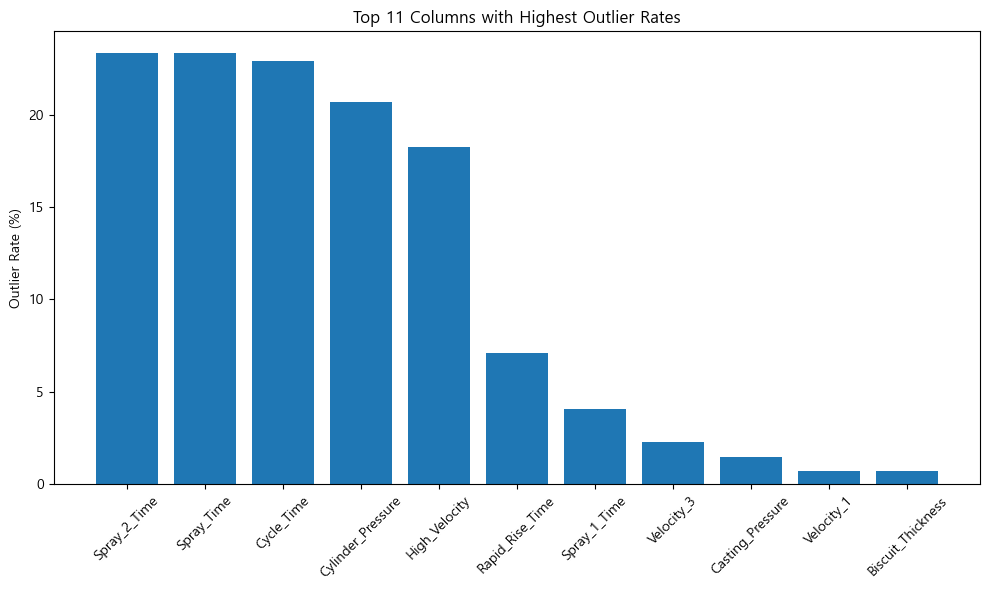

In [19]:
top11 = iqr_summary.sort_values("이상치 비율(%)", ascending=False).head(11)

labels = [col[1] for col in top11.index]   # 컬럼 이름
values = top11["이상치 비율(%)"]

plt.figure(figsize=(10,6))

plt.bar(labels, values)

plt.xticks(rotation=45)
plt.ylabel("Outlier Rate (%)")
plt.title("Top 11 Columns with Highest Outlier Rates")

plt.tight_layout()
plt.show()

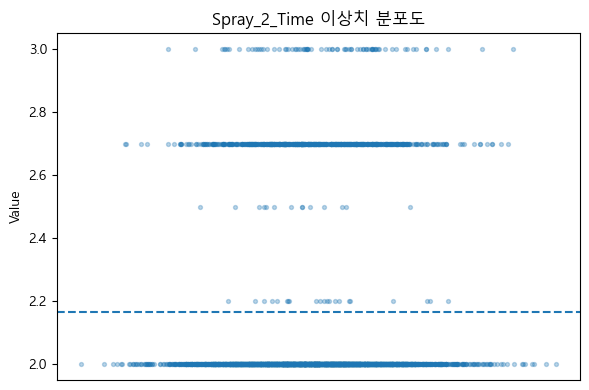

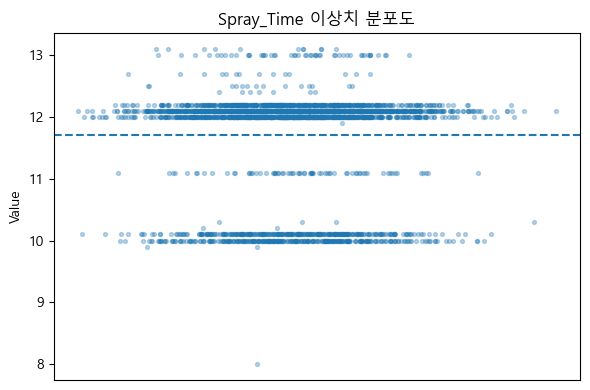

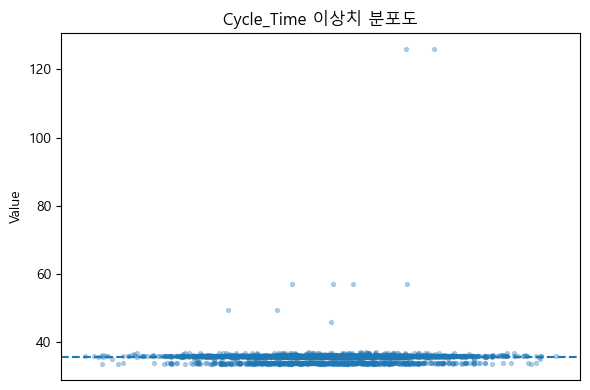

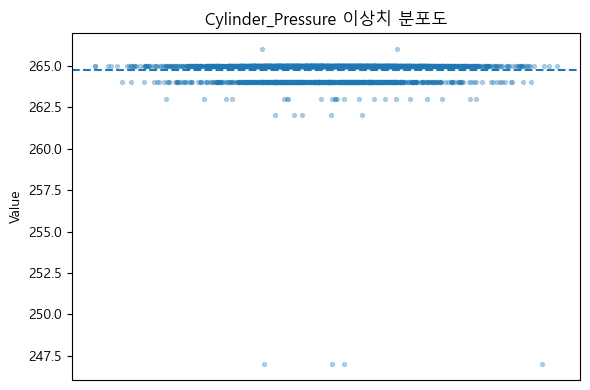

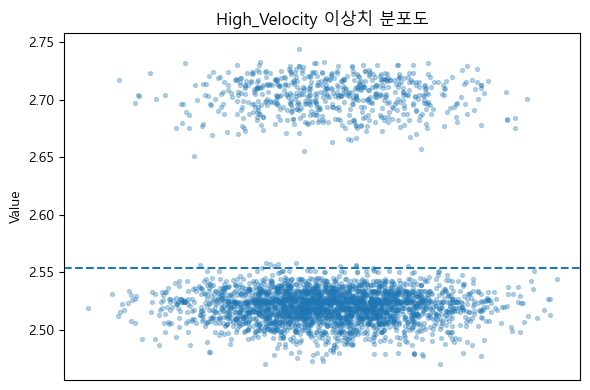

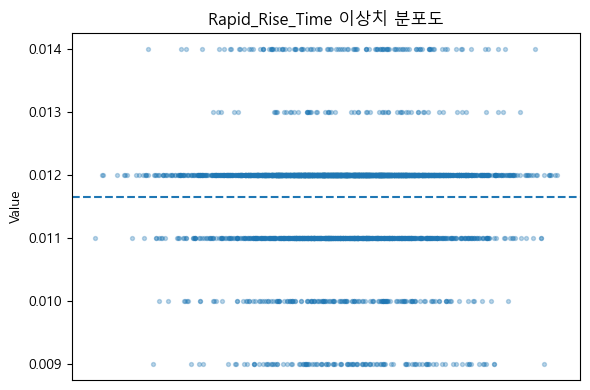

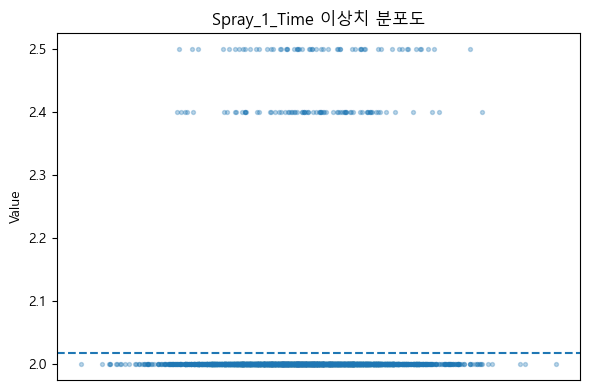

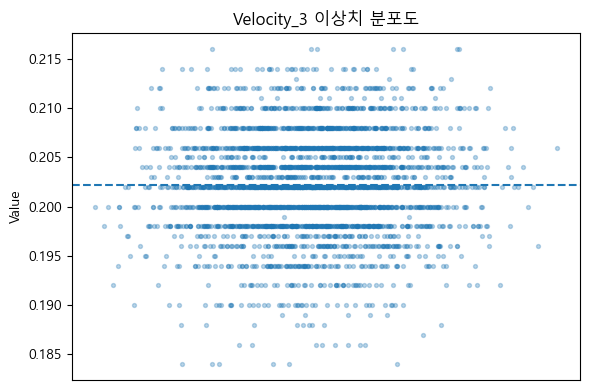

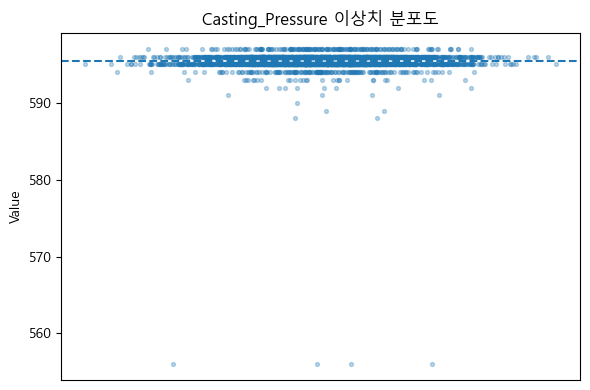

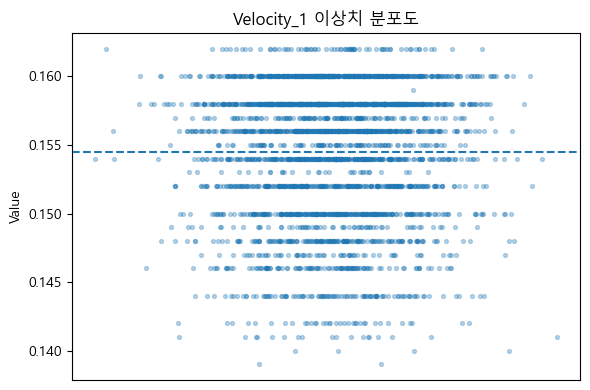

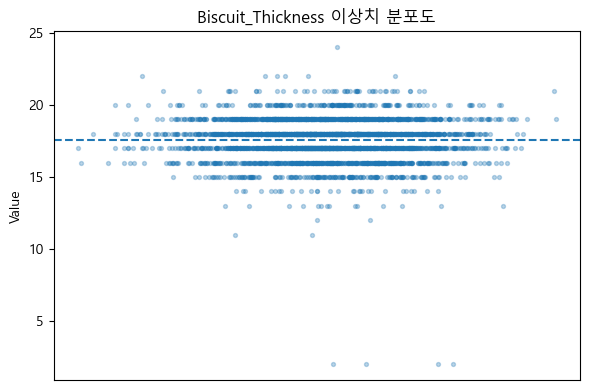

In [ ]:
top11_cols = iqr_summary.sort_values("이상치 비율(%)", ascending=False).head(11).index

for col in top11_cols:

    s = df_num[col].dropna()
    
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False

    plt.figure(figsize=(6,4))

    # x값 점 간격
    x = np.random.normal(0, 0.04, size=len(s))

    plt.scatter(x, s, alpha=0.3, s=8)

    # 평균 표시
    mean_val = s.mean()
    plt.axhline(mean_val, linestyle="--")

    plt.title(f"{col[1]} 이상치 분포도")
    plt.ylabel("Value")
    plt.xticks([])

    plt.tight_layout()
    plt.show()